In [1]:

import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.patheffects as pe
import pandas as pd
import seaborn as sns
from PIL import Image
from torchvision import transforms, models
from torchvision.models.segmentation import deeplabv3_resnet50

import json
import requests
import zipfile
import torch
import math
import io

In [2]:
# link = "128.32.162.150/bdd100k/bdd100k_images_100k.zip"

In [3]:
from glob import iglob


json_folder = "100k"
image_folder = "100k_images"

print(f"JSON folder: {os.listdir(json_folder)[0]}")
print(f"JSON folder: {os.listdir(json_folder)[1]}")
print(f"JSON folder: {os.listdir(json_folder)[2]}")

print("Json Folder: ")
print(os.listdir(image_folder))
print()
json_test = os.path.join(json_folder, "test")
print(f"JSON test: {json_test}")
json_train = os.path.join(json_folder, "train")
print(f"JSON train: {json_train}")
json_val = os.path.join(json_folder, "val")
print(f"JSON val: {json_val}")

print("Image Folder: ")
print(os.listdir(image_folder))
print()

image_test = os.path.join(image_folder, "test")
print(f"Image test: {image_test}")
image_train = os.path.join(image_folder, "train")
print(f"Image train: {image_train}")
image_val = os.path.join(image_folder, "val")
print(f"Image val: {image_val}")

print()

if os.path.exists(json_test):
    print(f"Folder {json_test} already exists")
else:
    print(f"Folder {json_test} does not exist")
if os.path.exists(image_test):
    print(f"Folder {image_test} already exists")
else:
    print(f"Folder {image_test} does not exist")
if os.path.exists(json_train):
    print(f"Folder {json_train} already exists")
else:
    print(f"Folder {json_train} does not exist")
if os.path.exists(image_train):
    print(f"Folder {image_train} already exists")
else:
    print(f"Folder {image_train} does not exist")
if os.path.exists(json_val):
    print(f"Folder {json_val} already exists")
else:
    print(f"Folder {json_val} does not exist")
if os.path.exists(image_val):
    print(f"Folder {image_val} already exists")

JSON folder: category_map.json
JSON folder: test
JSON folder: train
Json Folder: 
['train', 'val', 'test']

JSON test: 100k/test
JSON train: 100k/train
JSON val: 100k/val
Image Folder: 
['train', 'val', 'test']

Image test: 100k_images/test
Image train: 100k_images/train
Image val: 100k_images/val

Folder 100k/test already exists
Folder 100k_images/test already exists
Folder 100k/train already exists
Folder 100k_images/train already exists
Folder 100k/val already exists
Folder 100k_images/val already exists


In [4]:
print(f"Len train: {len(os.listdir(json_train)) }")
print(f"Len test: {len(os.listdir(json_test))}") 
print(f"Len val: {len(os.listdir(json_val))}")

print(f"Len train: {len(os.listdir(image_train))}")
print(f"Len test: {len(os.listdir(image_test))}")
print(f"Len val: {len(os.listdir(image_val))}")

Len train: 70000
Len test: 20000
Len val: 10000
Len train: 70000
Len test: 20000
Len val: 10000


In [12]:
for i in range(len(os.listdir(json_train))):
    j = json.load(open(os.path.join(json_train, os.listdir(json_train)[0])))
    
    name = j["name"] + ".jpg"
    if not os.path.exists(os.path.join(image_train, name)):
        print(f"Image {name} does not exist in {image_train}")
    img = Image.open(os.path.join(image_train, name))
    if img.size != (1280, 720):
        print(img.size)
    
    if i % 1000 == 0:
        print(f"Processing image {i} of {len(os.listdir(json_train))}")


Processing image 0 of 70000
Processing image 1000 of 70000
Processing image 2000 of 70000
Processing image 3000 of 70000
Processing image 4000 of 70000
Processing image 5000 of 70000
Processing image 6000 of 70000
Processing image 7000 of 70000
Processing image 8000 of 70000
Processing image 9000 of 70000
Processing image 10000 of 70000
Processing image 11000 of 70000
Processing image 12000 of 70000
Processing image 13000 of 70000


KeyboardInterrupt: 

In [5]:
# j = json.load(open(os.path.join(json_train, os.listdir(json_train)[0])))
# name = j["name"] + ".jpg"
# if os.path.exists(os.path.join(image_train, name)):
#     print(f"Image {name} already exists")
# else:
#     print(f"Image {name} does not exist in {image_train}")

Image b059de74-eef1f3e4.jpg already exists


(1280, 720)


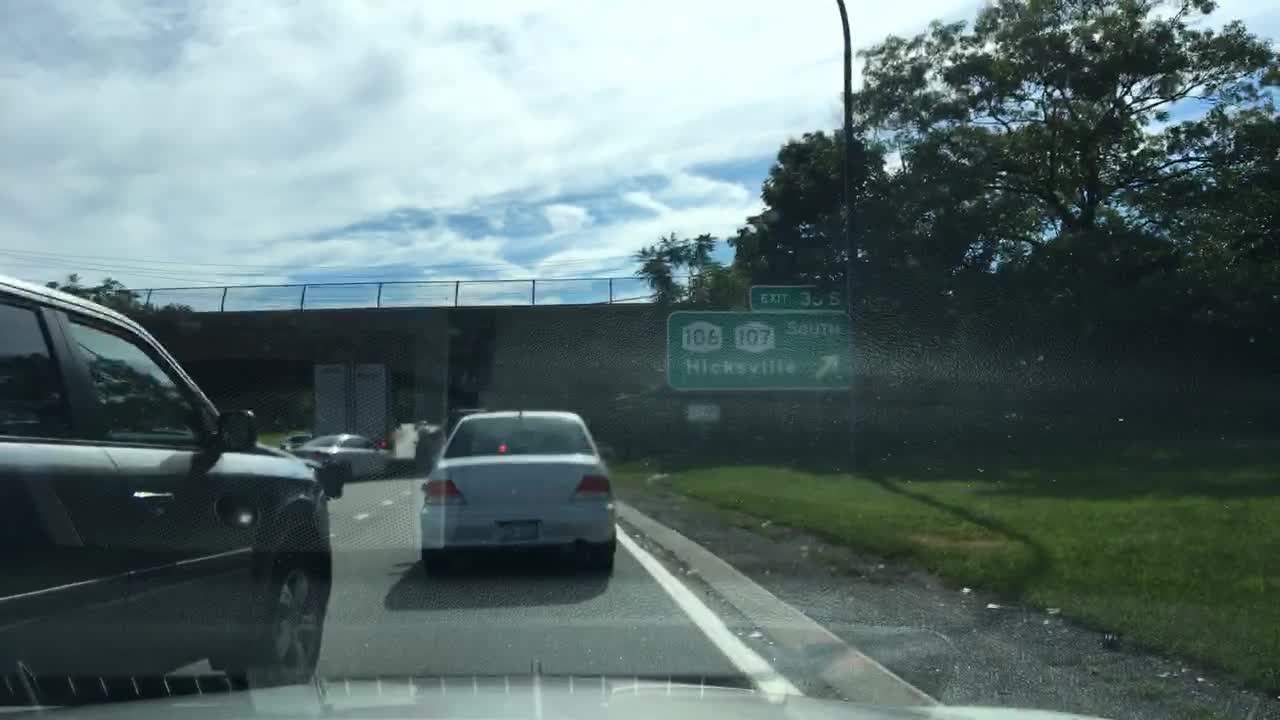

In [7]:
img = Image.open(os.path.join(image_train, name))
print(img.size)
img

In [18]:
print(j.keys())
print(j["name"])
print(j["frames"])
print(len(j["frames"]))
print(j["frames"][0].keys())

print(j["frames"][0]["objects"][0].keys())
print(len(j["frames"][0]["objects"]))
print(len(j["frames"][0]["objects"][0]))
print(j["frames"][0]["objects"][0])
print(j["frames"][0]["objects"])


roads = [obj for obj in j["frames"][0]["objects"] if obj["category"] == "area/drivable"]
roads

dict_keys(['name', 'frames', 'attributes'])
b059de74-eef1f3e4
[{'timestamp': 10000, 'objects': [{'category': 'traffic sign', 'id': 0, 'attributes': {'occluded': False, 'truncated': False, 'trafficLightColor': 'none'}, 'box2d': {'x1': 745.781914, 'y1': 283.886171, 'x2': 849.540215, 'y2': 315.209432}}, {'category': 'traffic sign', 'id': 1, 'attributes': {'occluded': False, 'truncated': False, 'trafficLightColor': 'none'}, 'box2d': {'x1': 667.473761, 'y1': 310.315172, 'x2': 859.328734, 'y2': 391.55988}}, {'category': 'traffic sign', 'id': 2, 'attributes': {'occluded': False, 'truncated': False, 'trafficLightColor': 'none'}, 'box2d': {'x1': 686.316661, 'y1': 403.306102, 'x2': 723.513033, 'y2': 422.883141}}, {'category': 'car', 'id': 3, 'attributes': {'occluded': True, 'truncated': False, 'trafficLightColor': 'none'}, 'box2d': {'x1': 278.972794, 'y1': 433.631394, 'x2': 312.253759, 'y2': 449.293024}}, {'category': 'car', 'id': 4, 'attributes': {'occluded': True, 'truncated': False, 'trafficL

[{'category': 'area/drivable',
  'id': 9,
  'attributes': {},
  'poly2d': [[323.168297, 675.034937, 'L'],
   [472.898782, 661.309642, 'C'],
   [625.124775, 666.30066, 'C'],
   [743.661409, 673.787183, 'C'],
   [654.157725, 583.506722, 'L'],
   [339.371204, 586.57781, 'L'],
   [323.168297, 675.034937, 'L']]}]

In [23]:
objects = j["frames"][0]["objects"]

roads = [obj for obj in objects if obj["category"] == "area/drivable"]
lanes = [obj for obj in objects if obj["category"].startswith("lane/")]
road_all = [
    obj for obj in objects if "area" in obj["category"] or "lane" in obj["category"]
]

print(f"Drivable areas : {len(roads)}")
print(f"Lane markings  : {len(lanes)}")
print(f"All road objs  : {len(road_all)}")
print()
print("Roads:", roads)
print()
print("Lanes:", lanes)

Drivable areas : 1
Lane markings  : 3
All road objs  : 4

Roads: [{'category': 'area/drivable', 'id': 29, 'attributes': {}, 'poly2d': [[500.603324, 442.748513, 'L'], [570.026279, 443.341057, 'L'], [1279.774383, 700.866208, 'L'], [1279.774383, 720.756371, 'L'], [1097.638786, 720.756371, 'L'], [1097.929942, 691.506642, 'C'], [472.669212, 672.601251, 'C'], [160.184423, 702.436483, 'C'], [500.603324, 442.748513, 'L']]}]

Lanes: [{'category': 'lane/road curb', 'id': 30, 'attributes': {'direction': 'parallel', 'style': 'solid'}, 'poly2d': [[704.253488, 469.600442, 'L'], [743.486599, 479.408931, 'L']]}, {'category': 'lane/double yellow', 'id': 31, 'attributes': {'direction': 'parallel', 'style': 'solid'}, 'poly2d': [[421.775093, 500.987599, 'L'], [370.77205, 541.202394, 'L']]}, {'category': 'lane/double yellow', 'id': 32, 'attributes': {'direction': 'parallel', 'style': 'solid'}, 'poly2d': [[404.120195, 492.159962, 'L'], [341.347217, 539.240697, 'L']]}]


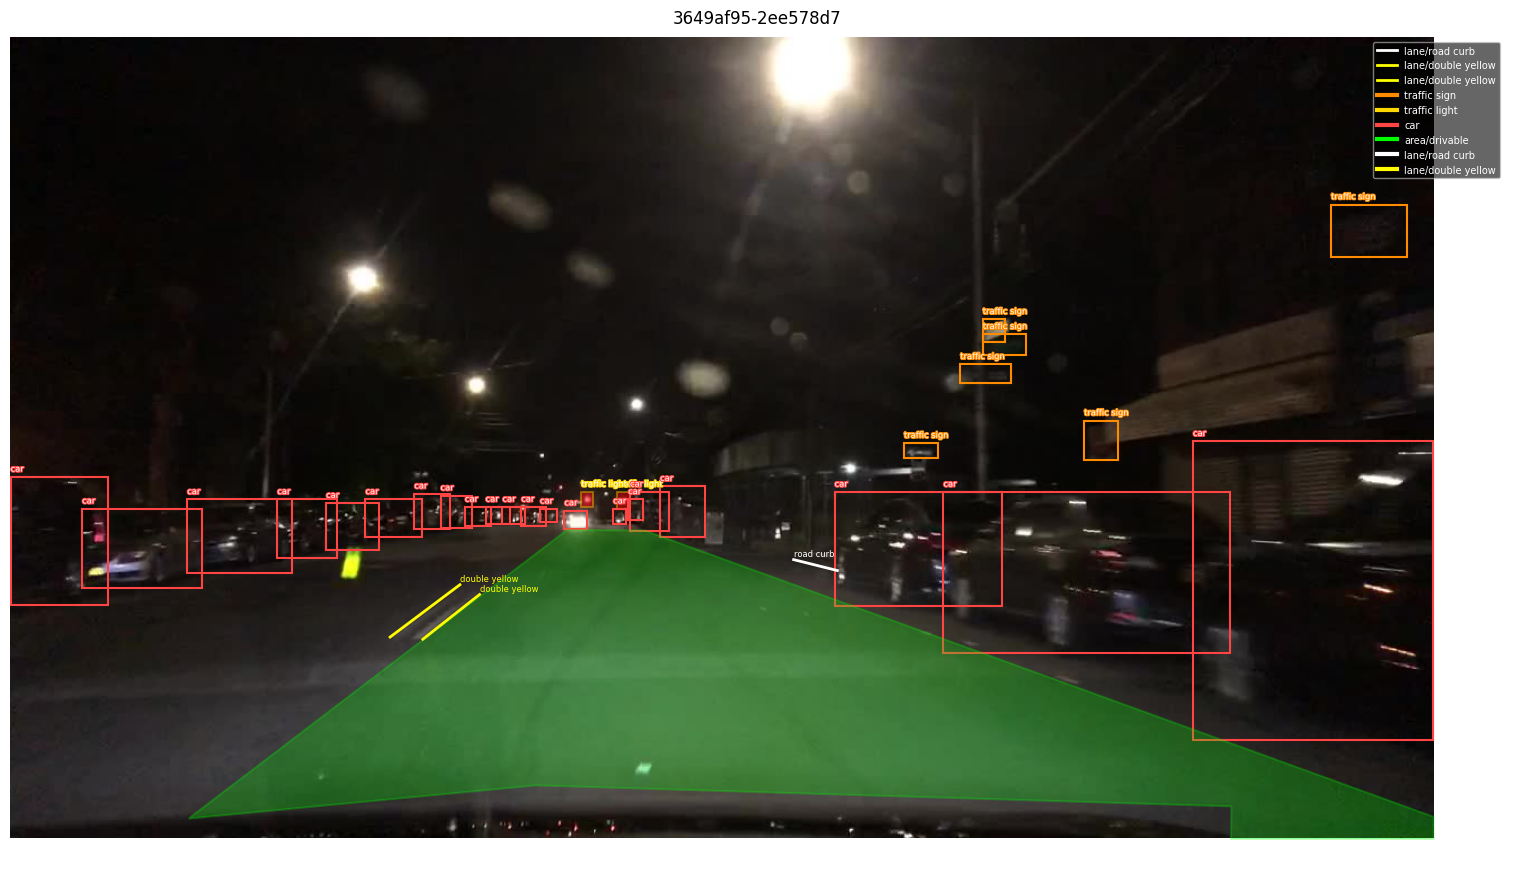

In [24]:
# Color map per category
COLORS = {
    "car": "#FF4444",
    "traffic light": "#FFD700",
    "traffic sign": "#FF8C00",
    "person": "#AA44FF",
    "rider": "#FF44AA",
    "truck": "#4444FF",
    "bus": "#00AAFF",
    "bike": "#00FFAA",
    "motor": "#FF6600",
    "area/drivable": "#00FF00",
    "lane/road curb": "#FFFFFF",
    "lane/double yellow": "#FFFF00",
    "lane/single white": "#CCCCCC",
}
DEFAULT_COLOR = "#888888"

TRAFFIC_LIGHT_COLORS = {
    "red": "red",
    "green": "lime",
    "yellow": "yellow",
    "none": "gray",
}

fig, ax = plt.subplots(1, 1, figsize=(16, 9))
ax.imshow(img)
ax.axis("off")
ax.set_title(j["name"], fontsize=12, pad=10)

for obj in objects:
    cat = obj["category"]
    color = COLORS.get(cat, DEFAULT_COLOR)

    # --- Bounding box objects (cars, traffic signs, lights, etc.) ---
    if "box2d" in obj:
        b = obj["box2d"]
        x1, y1, x2, y2 = b["x1"], b["y1"], b["x2"], b["y2"]
        w, h = x2 - x1, y2 - y1

        # For traffic lights, use the signal color as fill
        if cat == "traffic light":
            sig_color = TRAFFIC_LIGHT_COLORS.get(
                obj["attributes"].get("trafficLightColor", "none"), "gray"
            )
            rect = patches.Rectangle(
                (x1, y1),
                w,
                h,
                linewidth=1.5,
                edgecolor=color,
                facecolor=sig_color,
                alpha=0.4,
            )
        else:
            rect = patches.Rectangle(
                (x1, y1), w, h, linewidth=1.5, edgecolor=color, facecolor="none"
            )
        ax.add_patch(rect)

        # Label
        label = cat.split("/")[-1]
        txt = ax.text(x1, y1 - 3, label, fontsize=6, color="white", va="bottom")
        txt.set_path_effects([pe.withStroke(linewidth=1.5, foreground=color)])

    # --- Polygon objects (drivable area, lanes) ---
    elif "poly2d" in obj:
        pts = [(p[0], p[1]) for p in obj["poly2d"]]
        if len(pts) < 2:
            continue
        xs, ys = zip(*pts)

        if cat == "area/drivable":
            poly = patches.Polygon(
                list(zip(xs, ys)),
                closed=True,
                edgecolor=color,
                facecolor=color,
                alpha=0.25,
                linewidth=1.5,
            )
            ax.add_patch(poly)
        else:
            # Lanes: just draw the line
            ax.plot(xs, ys, color=color, linewidth=2, label=cat)
            ax.text(xs[0], ys[0] - 3, cat.split("/")[-1], fontsize=6, color=color)

# Legend (deduplicated)
seen = set()
for obj in objects:
    cat = obj["category"]
    if cat not in seen:
        color = COLORS.get(cat, DEFAULT_COLOR)
        ax.plot([], [], color=color, linewidth=3, label=cat)
        seen.add(cat)
ax.legend(
    loc="upper right", fontsize=7, framealpha=0.6, facecolor="black", labelcolor="white"
)

plt.tight_layout()
plt.show()

In [25]:
model = deeplabv3_resnet50(progress = True)
model

DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

In [26]:
iter = 2
max_iter = 10
power = 0.9
learning_rate = math.pow((1 - iter/max_iter), power)
crop = 512
batch_size = 16
output_stride = 16
decay = 0.9997

# data augmentation
# randomly scaling input images from 0.5 to 2
# and random left-right flipping during training

In [27]:
model.eval()

DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

In [ ]:
preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

input_tensor = preprocess(img)

input_batch = input_tensor.unsqueeze(0) 
    input_batch = input_batch.to('cuda')
    model.to('cuda')

with torch.no_grad():
    output = model(input_batch)['out'][0]
output_predictions = output.argmax(0)


In [25]:
output_predictions

tensor([[ 2,  2,  2,  ..., 10, 10, 10],
        [ 2,  2,  2,  ..., 10, 10, 10],
        [ 2,  2,  2,  ..., 10, 10, 10],
        ...,
        [10, 10, 10,  ..., 10, 10, 10],
        [10, 10, 10,  ..., 10, 10, 10],
        [10, 10, 10,  ..., 10, 10, 10]])

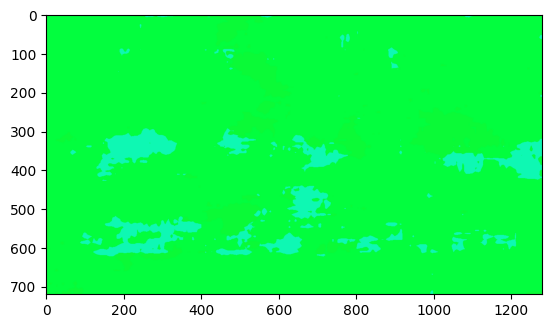

In [26]:
palette = torch.tensor([2 ** 25 - 1, 2 ** 15 - 1, 2 ** 21 - 1])
colors = torch.as_tensor([i for i in range(21)])[:, None] * palette
colors = (colors % 255).numpy().astype("uint8")

# plot the semantic segmentation predictions of 21 classes in each color
r = Image.fromarray(output_predictions.byte().cpu().numpy()).resize(img.size)
r.putpalette(colors)

import matplotlib.pyplot as plt
plt.imshow(r)